# Assignment 3

In this assignment, you'll delve deeper into understanding A/B testing using Bayesian statistics, multi-armed bandits, and sequential testing techniques. By the end of this assignment, you should be able to integrate advanced statistical concepts into real-world A/B testing scenarios.

You are provided with a new dataset, `data/campaign_data.csv`, for a new product launch. The dataset contains:

- `user_id`
- product_variant: the version of the product the user saw ("Standard", "New_Feature_A", "New_Feature_B")
- `clicked`: if the user clicked on the product (0 for no, 1 for yes)
- `purchased`: if the user purchased the product after clicking (0 for no, 1 for yes)

In [99]:
import pytensor
from pytensor import config

config.mode = "FAST_COMPILE"
config.cxx = ""

In [100]:
import pandas as pd
import numpy as np
import pymc as pm
import arviz as az
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import statsmodels
import scipy
import statsmodels.stats.api as sms
from statsmodels.stats.power import tt_ind_solve_power
from statsmodels.stats.proportion import proportion_effectsize
from scipy.stats import chi2_contingency

In [101]:
# Example 
true_slope = 5
true_intercept = 10
true_sigma = 1

num_points = 10

x_vals = np.linspace(0, 1, num_points)
true_y_vals = true_slope * x_vals + true_intercept
y_vals = true_y_vals + np.random.normal(scale=true_sigma, size=num_points)

true_params = {'slope': true_slope, 'intercept': true_intercept, 'sigma': true_sigma}

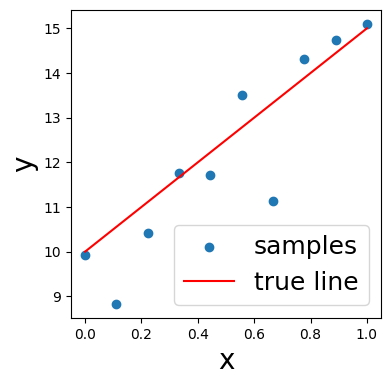

In [102]:
plt.figure(figsize=(4,4))
p1 = plt.scatter(x_vals, y_vals)
p2, = plt.plot(x_vals, true_y_vals, color='r')
plt.xlabel('x', fontsize=20)
plt.ylabel('y', fontsize=20)
plt.legend((p1, p2), ('samples', 'true line'), fontsize=18)

In [103]:
clf = LinearRegression()
clf.fit(x_vals.reshape(-1,1), y_vals)
preds = clf.predict(x_vals.reshape(-1,1))
resids = preds - y_vals

print('True Model:')
print('y_true = %s*x + %s'%(true_slope, true_intercept))
print('True sigma: %s\n'%true_params['sigma'])

print('Estimated Model:')
print('y_hat = %s*x + %s'%(clf.coef_[0], clf.intercept_))
print('Sd Residuals: %s'%(resids.std()))

mle_estimates = {'slope': clf.coef_[0], 'intercept': clf.intercept_, 'sigma': resids.std()}

True Model:
y_true = 5*x + 10
True sigma: 1

Estimated Model:
y_hat = 5.85381091122118*x + 9.220689009579758
Sd Residuals: 0.8551143990211398


In [104]:
with pm.Model() as model:
    #priors
    sigma = pm.Exponential("sigma", lam=1.0)
    intercept = pm.Normal("intercept", mu=0, sigma=20)
    slope = pm.Normal("slope", mu=0, sigma=20)

    #Likelihood
    likelihood = pm.Normal("y", mu=slope*x_vals + intercept, sigma=sigma, observed=y_vals)

    #posterior
    trace = pm.sample(1000, cores=4)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, intercept, slope]


Output()

/Users/natalapuzina/.virtualenvs/prep-venv/lib/python3.13/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 5 seconds.


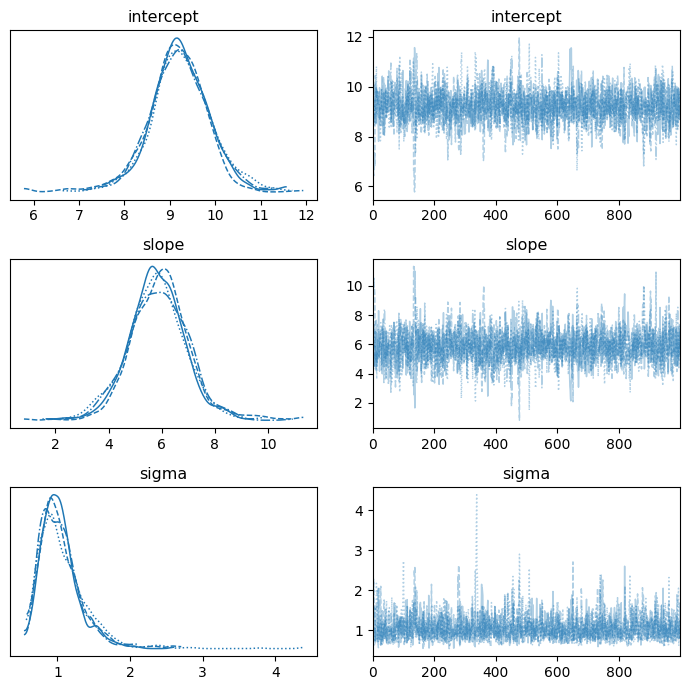

In [105]:

az.plot_trace(trace, figsize=(7, 7))
plt.tight_layout()

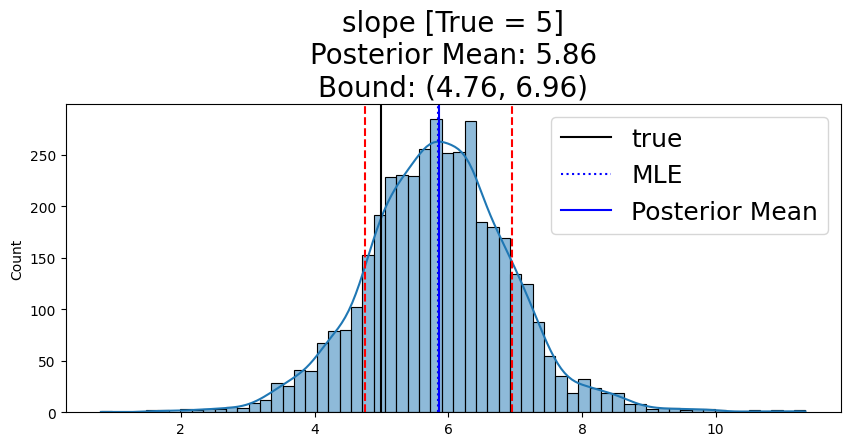

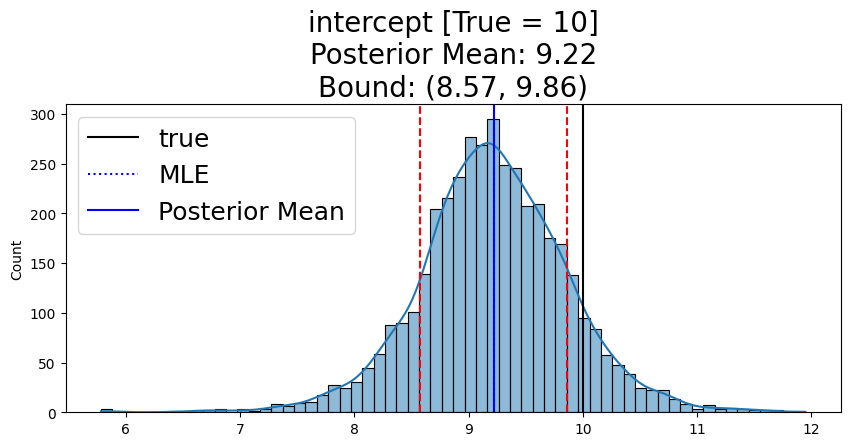

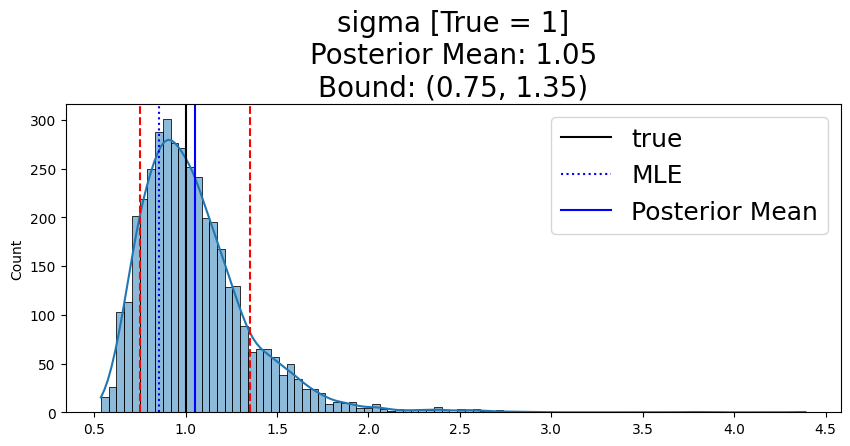

In [106]:
for var in ['slope', 'intercept', 'sigma']:
    plt.figure(figsize=(10,4))
    vals = trace.posterior[var].values.flatten()
    mean = round(vals.mean(), 2)
    lower = round(vals.mean() - vals.std(), 2)
    upper = round(vals.mean() + vals.std(), 2)
    sns.histplot(vals, kde=True)
    posterior_est = plt.axvline(mean, color='b')
    mle_est = plt.axvline(mle_estimates[var], color='b', linestyle='dotted')
    plt.axvline(lower, color='r', linestyle='--')
    plt.axvline(upper, color='r', linestyle='--')
    plt.title(f'{var} [True = {true_params[var]}]\nPosterior Mean: {mean}\nBound: ({lower}, {upper})', fontsize=20)
    true_val = plt.axvline(true_params[var], color='k')
    
    plt.legend((true_val, mle_est, posterior_est), ('true', 'MLE', 'Posterior Mean'), fontsize=18)
    
    plt.show()

## Bayesian A/B Testing:

1. Using `PyMC3`, construct a Bayesian model to estimate the posterior distributions for the conversion rates of each product variant. Display the distributions graphically.
2. Calculate the probability that "New_Feature_A" has a higher conversion rate than "Standard" and similarly for "New_Feature_B" versus "Standard".

In [107]:
data_campaign = pd.read_csv('data/campaign_data.csv')
data_campaign.head()

,user_id,product_variant,clicked,purchased
0,da4bc32c-d106-4a79-8125-ad69fec93a00,New_Feature_B,0,0
1,832ab2c6-2848-41c5-9dff-02e9c08ccef8,Standard,0,0
2,9c689e45-d002-4d94-a3cc-5609bdacc503,New_Feature_B,1,0
3,4c244bc6-2413-492e-9a3a-f15040dad640,New_Feature_B,0,0
4,fc4772d8-7081-46d4-973e-257a5cc7e205,Standard,0,0


In [108]:
click_rate = data_campaign.groupby('product_variant').clicked.sum()
purchase_rate = data_campaign[data_campaign['clicked'] == 1].groupby('product_variant').purchased.sum()

conversion_df = pd.concat([click_rate, purchase_rate], axis=1)

display(conversion_df.round(4))


,clicked,purchased
product_variant,,
New_Feature_A,8335,562
New_Feature_B,7449,441
Standard,6692,317


In [109]:
# Variant A
data_A = data_campaign[data_campaign['product_variant'] == 'New_Feature_A']
clicked_A = (data_A['clicked'] == 1).sum()                 # number of clickers
conversions_A = ((data_A['clicked'] == 1) & (data_A['purchased'] == 1)).sum()    # purchases among clickers

# Variant B
data_B = data_campaign[data_campaign['product_variant'] == 'New_Feature_B']
clicked_B = (data_B['clicked'] == 1).sum()
conversions_B = ((data_B['clicked'] == 1) & (data_B['purchased'] == 1)).sum()

# Standard
data_S = data_campaign[data_campaign['product_variant'] == 'Standard']
clicked_S = (data_S['clicked'] == 1).sum()
conversions_S = ((data_S['clicked'] == 1) & (data_S['purchased'] == 1)).sum()

print(clicked_A, conversions_A, clicked_B, conversions_B, clicked_S, conversions_S)


with pm.Model() as model:
    # Priors for conversion rates (given click)
    p_A = pm.Beta('p_A', alpha=2, beta=2)
    p_B = pm.Beta('p_B', alpha=2, beta=2)
    p_S = pm.Beta('p_S', alpha=2, beta=2)

    # Likelihood: observed conversions out of clickers
    obs_A = pm.Binomial('obs_A', n=clicked_A, p=p_A, observed=conversions_A)
    obs_B = pm.Binomial('obs_B', n=clicked_B, p=p_B, observed=conversions_B)
    obs_S = pm.Binomial('obs_S', n=clicked_S, p=p_S, observed=conversions_S)

    # Differences between variants
    delta_BA = pm.Deterministic('delta_BA', p_B - p_A)
    delta_SA = pm.Deterministic('delta_SA', p_S - p_A)
    delta_SB = pm.Deterministic('delta_SB', p_S - p_B)

    # Sample from the posterior 
    trace = pm.sample(2000, tune=1000)


8335 562 7449 441 6692 317


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p_A, p_B, p_S]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 9 seconds.


array([[<Axes: title={'center': 'p_A'}>, <Axes: title={'center': 'p_B'}>,
        <Axes: title={'center': 'p_S'}>],
       [<Axes: title={'center': 'delta_BA'}>,
        <Axes: title={'center': 'delta_SA'}>,
        <Axes: title={'center': 'delta_SB'}>]], dtype=object)

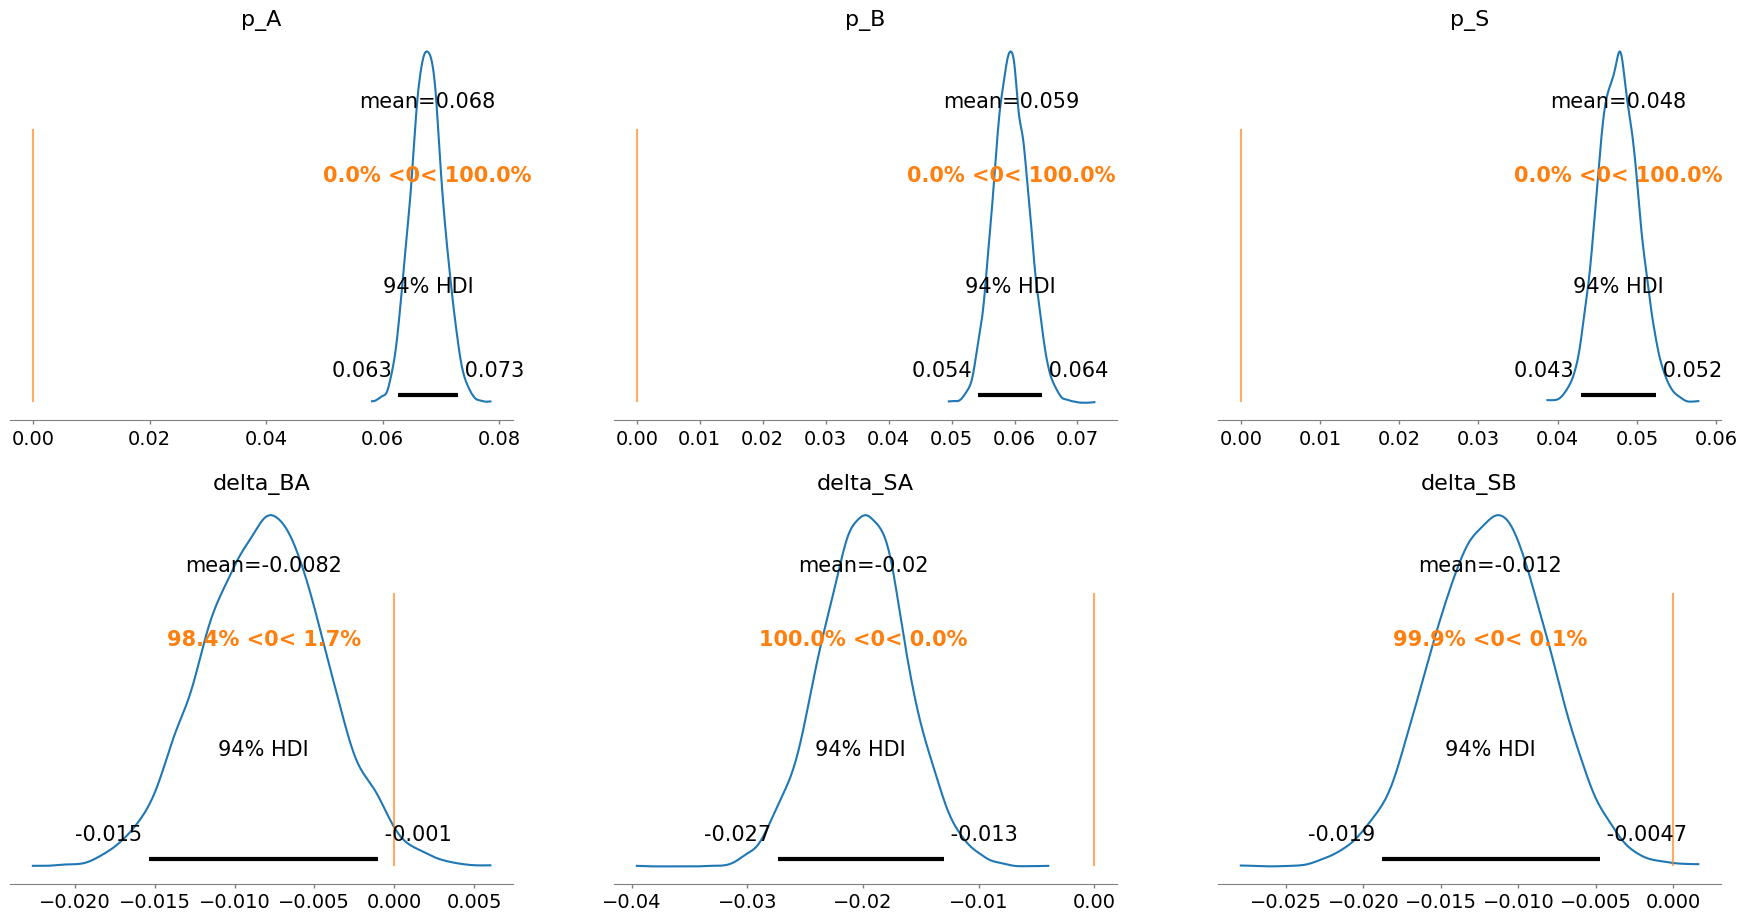

In [110]:
# Distributions of the conversion rates
az.plot_posterior(trace, var_names=['p_A', 'p_B', 'p_S', 'delta_BA', 'delta_SA', 'delta_SB'], ref_val=0)

In [111]:
post = trace.posterior
prob_A_vs_S = (post["delta_SA"] < 0).mean().item()
prob_B_vs_S = (post["delta_SB"] < 0).mean().item()

print(f"P(A has higher conversion than Standard) = {prob_A_vs_S:.4f}")
print(f"P(B has higher conversion than Standard) = {prob_B_vs_S:.4f}")

P(A has higher conversion than Standard) = 1.0000
P(B has higher conversion than Standard) = 0.9989


## Multi-Armed Bandits:

Imagine you are dynamically assigning users to different product variants based on the observed conversion rates.

3. Implement the $\varepsilon$-greedy algorithm to decide which variant to show to the users. Use a decaying epsilon value.
4. Simulate the multi-armed bandit scenario for 10,000 users and compare the cumulative rewards (i.e., purchases) obtained using the $\varepsilon$-greedy algorithm against a random assignment approach.

In [112]:
# True conversion rates and the number of variants
true_conversion_rates = np.array([
    conversions_A / clicked_A,
    conversions_B / clicked_B,
    conversions_S / clicked_S
])
n_arms = len(true_conversion_rates)

# Number of trials and epsilon
n_trials = 10000
epsilon = 1.0        
min_epsilon = 0.01   
decay = 0.995          

counts = np.zeros(n_arms)
wins = np.zeros(n_arms)

for _ in range(n_trials):
    # Epsilon greedy strategy
    if np.random.rand() < epsilon:
        # Explore: choose a random arm
        chosen_arm = np.random.randint(n_arms)
    else:
        # Exploit: choose the arm with the highest current conversion rate
        chosen_arm = np.argmax(wins / (counts + 1))

    # Simulate user interaction and update counts & wins
    reward = np.random.rand() < true_conversion_rates[chosen_arm]
    counts[chosen_arm] += 1
    wins[chosen_arm] += reward

    # Decay epsilon
    epsilon = max(min_epsilon, epsilon * decay)

print("Estimated rates:", wins / counts)
print("True rates     :", true_conversion_rates)

Estimated rates: [0.06787841 0.06547619 0.05319149]
True rates     : [0.06742651 0.05920258 0.04736999]


In [113]:
def run_epsilon_greedy(true_rates, n_trials=10_000,
                       eps_start=1.0, eps_min=0.01, decay=0.995,
                       random_state=42):
    rng = np.random.default_rng(random_state)
    n_arms = len(true_rates)
    
    counts = np.zeros(n_arms)   # how many times each arm chosen
    wins   = np.zeros(n_arms)   # how many purchases per arm
    
    epsilon = eps_start
    cum_rewards = np.zeros(n_trials)  # cumulative purchases over time
    
    for t in range(n_trials):
        # ε-greedy action selection
        if rng.random() < epsilon:
            # Explore: pick random arm
            chosen_arm = rng.integers(n_arms)
        else:
            # Exploit: pick arm with highest estimated conversion
            estimated_rates = wins / (counts + 1)  # +1 avoids division by zero
            chosen_arm = np.argmax(estimated_rates)
        
        # Simulate user: purchase happens with true probability of chosen arm
        reward = rng.random() < true_rates[chosen_arm]
        
        # Update stats
        counts[chosen_arm] += 1
        wins[chosen_arm]   += reward
        
        # Update cumulative reward
        cum_rewards[t] = cum_rewards[t-1] + reward if t > 0 else reward
        
        # Decay epsilon
        epsilon = max(eps_min, epsilon * decay)
    
    return cum_rewards, counts, wins


In [114]:
def run_random_policy(true_rates, n_trials=10_000, random_state=123):
    rng = np.random.default_rng(random_state)
    n_arms = len(true_rates)
    
    cum_rewards = np.zeros(n_trials)
    
    for t in range(n_trials):
        chosen_arm = rng.integers(n_arms)  # pure random choice
        reward = rng.random() < true_rates[chosen_arm]
        cum_rewards[t] = cum_rewards[t-1] + reward if t > 0 else reward
    
    return cum_rewards


In [115]:
# Run epsilon-greedy
cum_eps, counts_eps, wins_eps = run_epsilon_greedy(true_conversion_rates)

# Run random assignment
cum_rand = run_random_policy(true_conversion_rates)

print("True conversion rates (A, B, Standard):", true_conversion_rates)
print("Total purchases with ε-greedy:", int(cum_eps[-1]))
print("Total purchases with random :", int(cum_rand[-1]))
print("Extra purchases from ε-greedy:", int(cum_eps[-1] - cum_rand[-1]))


True conversion rates (A, B, Standard): [0.06742651 0.05920258 0.04736999]
Total purchases with ε-greedy: 647
Total purchases with random : 557
Extra purchases from ε-greedy: 90


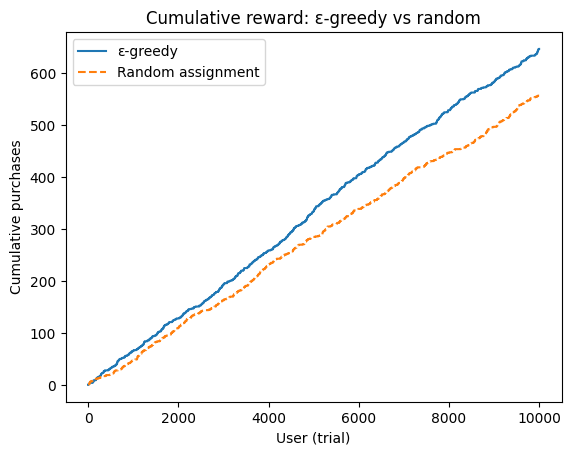

In [116]:
plt.plot(cum_eps, label='ε-greedy')
plt.plot(cum_rand, label='Random assignment', linestyle='--')
plt.xlabel('User (trial)')
plt.ylabel('Cumulative purchases')
plt.legend()
plt.title('Cumulative reward: ε-greedy vs random')
plt.show()

## Sequential Testing:

The idea behind sequential testing is to reduce the time taken to decide between product variants by continuously monitoring the results and potentially stopping the experiment early.

5. Implement a basic sequential testing approach using the Wald's Sequential Probability Ratio Test (SPRT). Determine if, at any point, you can conclude that one of the product variants is better than the "Standard" variant.
6. Compare the results of the sequential test with the Bayesian A/B test results. Discuss the advantages and disadvantages of each approach.

In [117]:
def sprt_variant_vs_standard(p_standard, p_variant,
                             alpha=0.05, beta=0.10,
                             max_n=10_000, random_state=None):
    """
    Wald's Sequential Probability Ratio Test (SPRT)
    for testing if a product variant is better than the Standard.

    H0: p_variant <= p_standard   (no improvement)
    H1: p_variant >  p_standard   (variant is better)

    Parameters
    p_standard : float
        Baseline conversion rate (Standard variant) - p0 in SPRT.
    p_variant : float
        Assumed improved conversion rate under H1 (variant) - p1 in SPRT.
        In your case you can use the observed rate of the new feature.
    alpha : float
        Type I error (probability of falsely claiming variant is better).
    beta : float
        Type II error (probability of missing a true improvement).
    max_n : int
        Maximum number of sequential users to simulate.
    random_state : int or None
        Seed for reproducibility.

    Returns
    result : dict
        {
          "decision": str,
          "n": number of users observed when test stopped,
          "log_LR": final log-likelihood ratio
        }
    """

    p0 = p_standard
    p1 = p_variant

    # SPRT boundaries
    A = (1 - beta) / alpha        # upper threshold (accept H1: variant better)
    B = beta / (1 - alpha)        # lower threshold (accept H0: not better)

    log_A = np.log(A)
    log_B = np.log(B)

    log_LR = 0.0  # log likelihood ratio
    n = 0

    while n < max_n:
        # Simulate ONE user assigned to the VARIANT:
        # reward = 1 if purchase, 0 otherwise
        x = np.random.binomial(1, p1)   # here we simulate under the "true" p1

        # Update log likelihood ratio:
        # log Λ += log( P(x | p1) / P(x | p0) )
        if x == 1:
            log_LR += np.log(p1 / p0)
        else:
            log_LR += np.log((1 - p1) / (1 - p0))

        n += 1

        # Decision rules:
        # Accept H1 (variant better) if log_LR >= log(A)
        if log_LR >= log_A:
            return {
                "decision": "Reject H0: variant is BETTER than Standard",
                "n": n,
                "log_LR": log_LR
            }

        # Accept H0 (no improvement) if log_LR <= log(B)
        if log_LR <= log_B:
            return {
                "decision": "Fail to reject H0: NO evidence variant is better than Standard",
                "n": n,
                "log_LR": log_LR
            }

    # If we reach max_n without crossing any boundary:
    return {
        "decision": "Inconclusive: maximum sample size reached",
        "n": n,
        "log_LR": log_LR
    }


In [118]:
p_S = conversions_S / clicked_S
p_A = conversions_A / clicked_A
p_B = conversions_B / clicked_B

res_A = sprt_variant_vs_standard(p_standard=p_S, p_variant=p_A,
                                 alpha=0.05, beta=0.10, random_state=42)
res_B = sprt_variant_vs_standard(p_standard=p_S, p_variant=p_B,
                                 alpha=0.05, beta=0.10, random_state=43)

print("A vs Standard:", res_A)
print("B vs Standard:", res_B)


A vs Standard: {'decision': 'Fail to reject H0: NO evidence variant is better than Standard', 'n': 441, 'log_LR': np.float64(-2.2716459792493953)}
B vs Standard: {'decision': 'Reject H0: variant is BETTER than Standard', 'n': 1197, 'log_LR': np.float64(2.935084634963733)}


## Bonus (Optional):

7. Integrate the multi-armed bandit with Bayesian updating. After each user interaction, update the conversion rate distribution for the chosen variant using PyMC3 and use it to guide the next $\varepsilon$-greedy decision.

In [119]:
def run_epsilon_greedy_bayesian(true_rates,
                                n_trials=10_000,
                                eps_start=1.0,
                                eps_min=0.01,
                                decay=0.995,
                                random_state=42):
    rng = np.random.default_rng(random_state)
    n_arms = len(true_rates)
    
    # Beta(2,2) prior for each arm (same as in your PyMC model)
    alpha = np.full(n_arms, 2.0)
    beta  = np.full(n_arms, 2.0)
    
    epsilon = eps_start
    cum_rewards = np.zeros(n_trials)
    choices = np.zeros(n_arms, dtype=int)
    
    for t in range(n_trials):
        # Posterior means from current Beta(α,β)
        posterior_means = alpha / (alpha + beta)
        
        # ε-greedy decision
        if rng.random() < epsilon:
            # explore
            chosen_arm = rng.integers(n_arms)
        else:
            # exploit best posterior mean
            chosen_arm = np.argmax(posterior_means)
        
        # Simulate user: reward ~ Bernoulli(true_rate)
        reward = rng.random() < true_rates[chosen_arm]
        
        # Bayesian update for chosen arm
        if reward:
            alpha[chosen_arm] += 1   # one more success
        else:
            beta[chosen_arm] += 1    # one more failure
        
        # Tracking
        choices[chosen_arm] += 1
        cum_rewards[t] = cum_rewards[t-1] + reward if t > 0 else reward
        
        # Decay epsilon
        epsilon = max(eps_min, epsilon * decay)
    
    return cum_rewards, choices, alpha, beta


In [120]:
cum_bayes, choices_bayes, alpha_bayes, beta_bayes = run_epsilon_greedy_bayesian(
    true_conversion_rates
)

print("True conversion rates :", true_conversion_rates)
print("Posterior means       :", alpha_bayes / (alpha_bayes + beta_bayes))
print("Times each arm chosen :", choices_bayes)
print("Total purchases       :", int(cum_bayes[-1]))


True conversion rates : [0.06742651 0.05920258 0.04736999]
Posterior means       : [0.06624935 0.0625     0.04395604]
Times each arm chosen : [9581  332   87]
Total purchases       : 654
